In [26]:
# Load the CSV file using pandas
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.style.use('ggplot') 

# Load the Groceries Dataset 
df = pd.read_csv("C:/Users/Kumar/Downloads/Groceries_dataset (1).csv")

In [27]:
# Display the first 10 rows
df.head(10)

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit


In [28]:
# Identify the columns representing transaction ID and items
# First, check the column names:
print(df.columns)

Index(['Member_number', 'Date', 'itemDescription'], dtype='object')


Transaction ID: There is usually no single TransactionID column. Instead, each transaction is identified by the combination of: Member_number Date 
This is because a customer can shop multiple times on different dates. 

Items column: itemDescription 

In [29]:
# Report the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 38765
Number of columns: 3


# Question - What does a transaction represent in this dataset? 

Answer: A transaction represents a single shopping visit made by a customer. It contains all the grocery items purchased together during that visit. In this dataset, a transaction is identified by the combination of Member_number and Date, while itemDescription lists the individual items purchased in that transaction. 

# Convert the dataset into a list of transactions
- Member_number
- Date
- itemDescription

Group the data by Member_number and Date so that each shopping trip becomes one transaction.

In [30]:
# Group items by transaction (Member_number + Date)
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list)

# Convert to a list of transactions
transactions = transactions.tolist()

# Display the first 5 transactions
transactions[:5]

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables']]

# Convert transactions into a one-hot encoded basket matrix

Use TransactionEncoder from the mlxtend library.
from mlxtend.preprocessing import TransactionEncoder

In [31]:
# Install the mlxtend library first
!pip install mlxtend

# Import necessary libraries
from mlxtend.preprocessing import TransactionEncoder  # Correct import path for TransactionEncoder
import pandas as pd  # Import pandas for DataFrame creation

# Create TransactionEncoder object
te = TransactionEncoder()

# Transform transactions
te_array = te.fit(transactions).transform(transactions)

# Create basket matrix
basket = pd.DataFrame(te_array, columns=te.columns_)

# Display first 5 rows
basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [32]:
# Display the shape of the basket matrix
print("Basket Matrix Shape:", basket.shape)

Basket Matrix Shape: (14963, 167)


In [33]:
# Import Apriori
from mlxtend.frequent_patterns import apriori

In [34]:
# Run Apriori (Support = 0.01)
# Apply Apriori with minimum support = 0.01
frequent_itemsets_01 = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

# Add a column showing the number of items in each itemset
frequent_itemsets_01['length'] = frequent_itemsets_01['itemsets'].apply(len)

In [35]:
# Display Top 10 Frequent Itemsets
# Sort by support in descending order.

top10_01 = frequent_itemsets_01.sort_values(
    by='support',
    ascending=False
)
top10_01.head(10)

,support,itemsets,length
62,0.157923,(whole milk),1
40,0.122101,(other vegetables),1
46,0.110005,(rolls/buns),1
52,0.097106,(soda),1
63,0.085879,(yogurt),1
47,0.069572,(root vegetables),1
57,0.067767,(tropical fruit),1
5,0.060683,(bottled water),1
49,0.060349,(sausage),1
15,0.053131,(citrus fruit),1


In [36]:
# Total Number of Frequent Itemsets
print("Total Frequent Itemsets:", len(frequent_itemsets_01))

Total Frequent Itemsets: 69


In [37]:
# Largest Itemset Length
print("Largest Itemset Length:",
      frequent_itemsets_01['length'].max())

Largest Itemset Length: 2


In [38]:
# Repeat for Support = 0.02
frequent_itemsets_02 = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets_02['length'] = frequent_itemsets_02['itemsets'].apply(len)

In [39]:
# Top 10
frequent_itemsets_02.sort_values(
    by='support',
    ascending=False
).head(10)

,support,itemsets,length
36,0.157923,(whole milk),1
24,0.122101,(other vegetables),1
28,0.110005,(rolls/buns),1
32,0.097106,(soda),1
37,0.085879,(yogurt),1
29,0.069572,(root vegetables),1
33,0.067767,(tropical fruit),1
4,0.060683,(bottled water),1
30,0.060349,(sausage),1
10,0.053131,(citrus fruit),1


In [40]:
# Total Itemsets
print("Total Frequent Itemsets:",
      len(frequent_itemsets_02))
# Largest Length
print("Largest Itemset Length:",
      frequent_itemsets_02['length'].max())

Total Frequent Itemsets: 38
Largest Itemset Length: 1


Usually: Support Result 

0.01 - More frequent itemsets 

0.02 - Fewer frequent itemsets 

Why? 

Increasing the minimum support threshold makes the algorithm more selective. Itemsets that occur less frequently are filtered out. 
1. Top 10 Frequent Itemsets 
These are the itemsets with the highest support values, meaning they appear most often in customer transactions. 
 
2. Total Number of Frequent Itemsets 
This is the total count of itemsets that satisfy the specified minimum support threshold. 
 
3. Largest Itemset Length 
This indicates the maximum number of items found together in any frequent itemset. For example, a length of 3 means the algorithm found a frequent combination containing three items. 

In [41]:
# Import association_rules
from mlxtend.frequent_patterns import association_rules

# Generate Association Rules
# Use the frequent itemsets you created (for example, with min_support = 0.01).

# Generate association rules
rules = association_rules(
    frequent_itemsets_01,
    metric="confidence",
    min_threshold=0.1
)
# Why metric="confidence"?

# This tells the algorithm to generate rules and keep those with a confidence of at least 0.1 (10%). Later, you'll apply the assignment's required filters.

# Display Required Columns
rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']].head()

,antecedents,consequents,support,confidence,lift
0,(other vegetables),(whole milk),0.014837,0.121511,0.769430
1,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
2,(soda),(whole milk),0.011629,0.119752,0.758296
3,(yogurt),(whole milk),0.011161,0.129961,0.822940


In [42]:
# Task 1: Display the Top 10 Rules with the Highest Lift
top10_lift = rules.sort_values(
    by='lift',
    ascending=False
)

top10_lift[['antecedents',
            'consequents',
            'support',
            'confidence',
            'lift']].head(10)

# This sorts all rules by Lift from highest to lowest.

# Task 2: Filter Rules

# Keep only rules where:
# Confidence >= 0.50  # Changed from ≥ to >= (standard ASCII)
# Lift >= 1.20        # Changed from ≥ to >= (standard ASCII)
filtered_rules = rules[
    (rules['confidence'] >= 0.50) &
    (rules['lift'] >= 1.20)
]

filtered_rules[['antecedents',
                'consequents',
                'support',
                'confidence',
                'lift']]

,antecedents,consequents,support,confidence,lift


In [43]:
# Count the Number of Filtered Rules
print("Number of filtered rules:", len(filtered_rules))

Number of filtered rules: 0


Antecedents:  {butter}		 		

Consequents:   {whole milk}	   	    

Support:   0.025	

Confidence:  0.62

Lift:  2.10

Means:

Antecedent: Butter 
Consequent: Whole milk

- Support = 0.025: 2.5% of all transactions contain both butter and whole milk. 
- Confidence = 0.62: 62% of customers who bought butter also bought whole milk. 
- Lift = 2.10: Customers who buy butter are 2.1 times more likely to buy whole milk than an average customer.

# Manual Calculations  
Given
Total Transactions (N) = 100
Transactions containing Bread (A) = 40
Transactions containing Milk (B) = 50
Transactions containing both Bread and Milk (A ∩ B) = 30

Association Rule:

Bread → Milk

1. Support 
Formula- 

 Support(A→B) = Transactions containing both A and B / Total Transactions 

Calculation 

Support = 30/100   
Support = 0.30 (30%) 
 
30% of all transactions contain both Bread and Milk.

2. Confidence
Formula
Confidence(A→B)= Transactions containing both A and B / Transactions containing A

Calculation
Confidence = 30/40
Confidence = 0.75 (75%)

Among customers who bought Bread, 75% also bought Milk.

3. Lift
Step 1: Calculate the Support of Milk
Support(Milk) = 50/100 = 0.50

Step 2: Apply the Lift Formula
Lift = Confidence(Bread→Milk)/ Support(Milk)

Calculation
Lift = 0.75/0.50
Lift=1.50

Customers who buy Bread are 1.5 times more likely to buy Milk compared to a randomly selected customer.


Explanation: 
- Support (30%) shows that Bread and Milk are purchased together in 30% of all transactions.
- Confidence (75%) indicates that 75% of customers who buy Bread also buy Milk.
- Lift (1.50) is greater than 1, indicating a positive association between Bread and Milk. Customers who buy Bread are 1.5 times more likely to buy Milk than expected by chance.

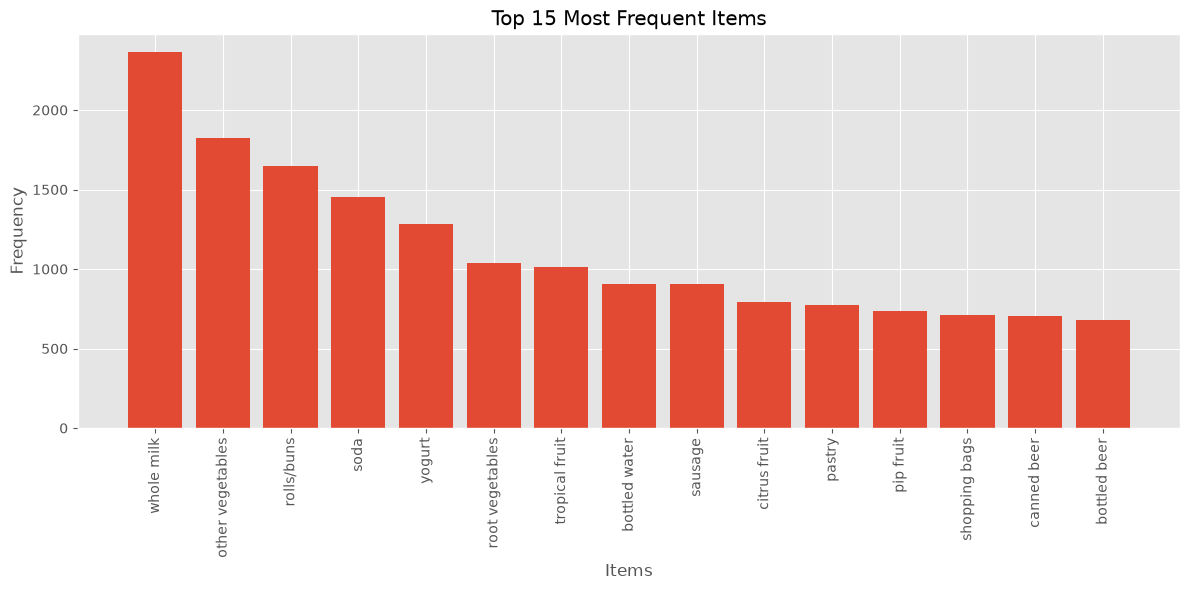

In [44]:
# Count the frequency of each item
item_counts = basket.sum().sort_values(ascending=False)

# Select the top 15 items
top15_items = item_counts.head(15)

# Plot the bar chart
plt.figure(figsize=(12,6))
plt.bar(top15_items.index, top15_items.values)

plt.title("Top 15 Most Frequent Items")
plt.xlabel("Items")
plt.ylabel("Frequency")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [45]:
# Generate frequent itemsets
from mlxtend.frequent_patterns import apriori

frequent_itemsets_01 = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets_01['length'] = frequent_itemsets_01['itemsets'].apply(len)

frequent_itemsets_01.head()

,support,itemsets,length
0,0.021386,(UHT-milk),1
1,0.033950,(beef),1
2,0.021787,(berries),1
3,0.016574,(beverages),1
4,0.045312,(bottled beer),1


In [46]:
# Generate association rules
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets_01,
    metric="confidence",
    min_threshold=0.1
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(other vegetables),(whole milk),0.122101,0.157923,0.014837,0.121511,0.769430,1.0,-0.004446,0.958551,-0.254477,0.055948,-0.043241,0.107730
1,(rolls/buns),(whole milk),0.110005,0.157923,0.013968,0.126974,0.804028,1.0,-0.003404,0.964550,-0.214986,0.055000,-0.036752,0.107711
2,(soda),(whole milk),0.097106,0.157923,0.011629,0.119752,0.758296,1.0,-0.003707,0.956636,-0.260917,0.047776,-0.045329,0.096694
3,(yogurt),(whole milk),0.085879,0.157923,0.011161,0.129961,0.822940,1.0,-0.002401,0.967861,-0.190525,0.047975,-0.033206,0.100317


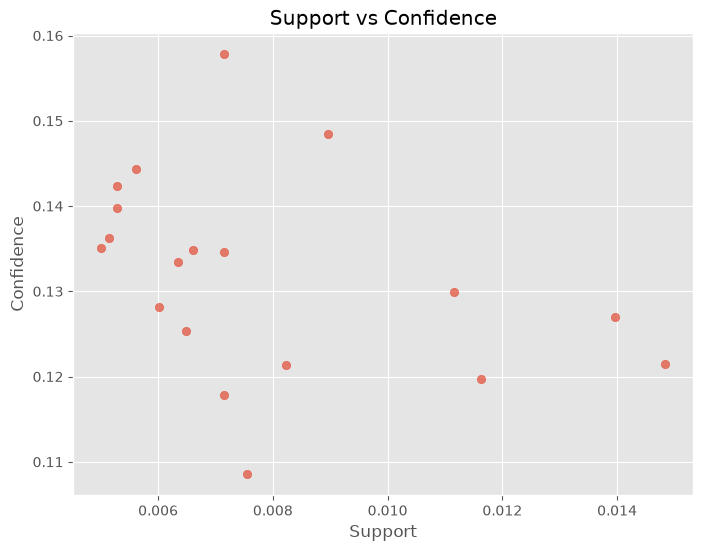

In [57]:
# create the scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    rules['support'],
    rules['confidence'],
    alpha=0.7
)

plt.title("Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.grid(True)

plt.show()

In [48]:
print(basket.dtypes.head())
basket = basket.astype(bool)
frequent_itemsets_01 = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets_01['length'] = frequent_itemsets_01['itemsets'].apply(len)

Instant food products    bool
UHT-milk                 bool
abrasive cleaner         bool
artif. sweetener         bool
baby cosmetics           bool
dtype: object


In [49]:
print(transactions[:3])
print(basket.columns[:10])

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['whole milk', 'pastry', 'salty snack'], ['canned beer', 'misc. beverages']]
Index(['Instant food products', 'UHT-milk', 'abrasive cleaner',
       'artif. sweetener', 'baby cosmetics', 'bags', 'baking powder',
       'bathroom cleaner', 'beef', 'berries'],
      dtype='object')


In [50]:
print(frequent_itemsets_01.head())

    support        itemsets  length
0  0.021386      (UHT-milk)       1
1  0.033950          (beef)       1
2  0.021787       (berries)       1
3  0.016574     (beverages)       1
4  0.045312  (bottled beer)       1


In [51]:
print(frequent_itemsets_01.shape)

(69, 3)


In [52]:
# Create the association rules

from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets_01,
    metric="confidence",
    min_threshold=0.1
)

print(rules.head())
print(rules.shape)

          antecedents   consequents  antecedent support  consequent support  \
0  (other vegetables)  (whole milk)            0.122101            0.157923   
1        (rolls/buns)  (whole milk)            0.110005            0.157923   
2              (soda)  (whole milk)            0.097106            0.157923   
3            (yogurt)  (whole milk)            0.085879            0.157923   

    support  confidence      lift  representativity  leverage  conviction  \
0  0.014837    0.121511  0.769430               1.0 -0.004446    0.958551   
1  0.013968    0.126974  0.804028               1.0 -0.003404    0.964550   
2  0.011629    0.119752  0.758296               1.0 -0.003707    0.956636   
3  0.011161    0.129961  0.822940               1.0 -0.002401    0.967861   

   zhangs_metric   jaccard  certainty  kulczynski  
0      -0.254477  0.055948  -0.043241    0.107730  
1      -0.214986  0.055000  -0.036752    0.107711  
2      -0.260917  0.047776  -0.045329    0.096694  
3      -0.

In [53]:
# Lower support
frequent_itemsets_01 = apriori(
    basket,
    min_support=0.005,   # LOWER THAN BEFORE
    use_colnames=True
)

frequent_itemsets_01['length'] = frequent_itemsets_01['itemsets'].apply(len)

In [54]:
# Generate more rules
rules = association_rules(
    frequent_itemsets_01,
    metric="confidence",
    min_threshold=0.1
)

In [55]:
print(rules.shape)

(19, 14)


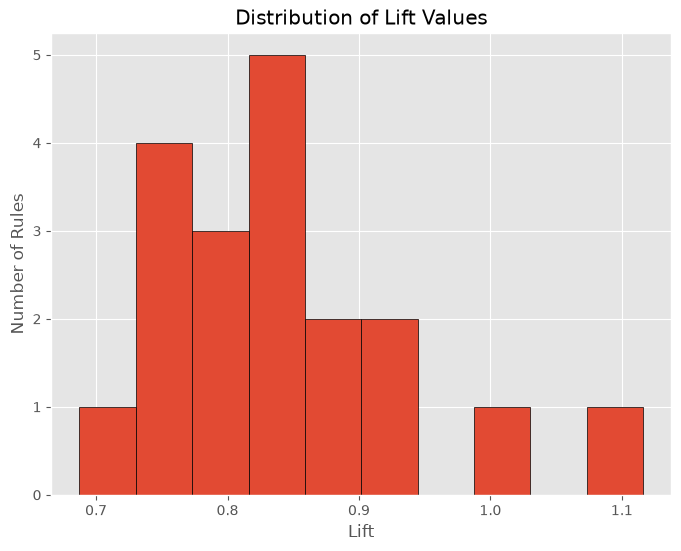

In [58]:
# Histogram: Distribution of Lift Values
plt.figure(figsize=(8,6))

plt.hist(
    rules['lift'],
    bins=10,
    edgecolor='black'
)

plt.title("Distribution of Lift Values")
plt.xlabel("Lift")
plt.ylabel("Number of Rules")

plt.show()

Interpretation Questions:

1. Which items appear most frequently?
   
The most frequently appearing items are those with the highest bars in the bar chart.
In the Groceries dataset, commonly top items include:
- whole milk
- other vegetables
- rolls/buns
- soda
- yogurt

2. Where do the strongest rules appear on the scatter plot?

Upper-right region of the scatter plot. Because:
- High support → occurs frequently
- High confidence → strong relationship
So points near the top-right are the strongest meaningful associations.

3. Why is Lift useful when evaluating association rules?

Lift is important because it tells us whether an association is real or just coincidence.

Explanation:
Lift = 1 → no relationship (independent items)
Lift > 1 → positive association (items likely bought together)
Lift < 1 → negative association

Why it matters:

Confidence alone can be misleading (popular items inflate confidence).
Lift corrects this by comparing against expected probability.So Lift helps identify true meaningful relationships, not just frequent items.

In [61]:
# Task 1: Create a Pivot Table
# Create a pivot table that counts how many times each grocery item appears in the dataset.
import pandas as pd

# Create pivot table
pivot_table = pd.pivot_table(
    df,
    index='itemDescription',
    values='Member_number',      # Counts the transactions
    aggfunc='count'
)

# Rename the column
pivot_table.columns = ['Transaction Count']

# Display the pivot table
pivot_table.head()

,Transaction Count
itemDescription,
Instant food products,60
UHT-milk,323
abrasive cleaner,22
artif. sweetener,29
baby cosmetics,3


In [62]:
# Task 2: Identify the Top 10 Most Frequently Purchased Items

# Sort the pivot table in descending order.
top10_items = pivot_table.sort_values(
    by='Transaction Count',
    ascending=False
)

# Display top 10
top10_items.head(10)

,Transaction Count
itemDescription,
whole milk,2502
other vegetables,1898
rolls/buns,1716
soda,1514
yogurt,1334
root vegetables,1071
tropical fruit,1032
bottled water,933
sausage,924


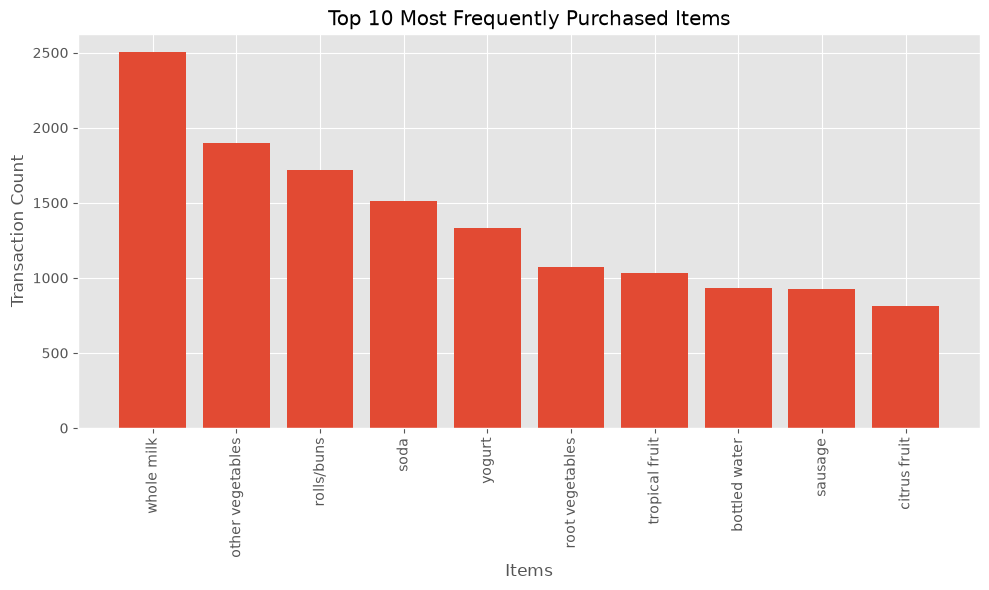

In [63]:
# Task 3: Create a Bar Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(
    top10_items.head(10).index,
    top10_items.head(10)['Transaction Count']
)
plt.title("Top 10 Most Frequently Purchased Items")
plt.xlabel("Items")
plt.ylabel("Transaction Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Interpretation Questions
1. Which item appears most frequently in the dataset?

Answer: The item with the highest transaction count in the pivot table is the most frequently purchased item. In the Groceries dataset, whole milk is typically the most frequently purchased item.

2. Why is it useful to identify high-frequency items before applying Apriori?

Answer: Identifying high-frequency items helps us understand customer purchasing behavior before applying the Apriori algorithm. It highlights popular products, provides an overview of the dataset, and helps explain why certain items may appear in many frequent itemsets and association rules.

3. Do the most frequent items necessarily produce the strongest association rules? Explain.

Answer: No. The most frequently purchased items do not always produce the strongest association rules. A popular item may appear in many transactions independently, resulting in weak associations with other items. Strong association rules depend on support, confidence, and especially lift, not just the frequency of individual items. Therefore, an item can be very common but still have a low lift with another item, indicating a weak relationship.